<a href="https://colab.research.google.com/github/macsrc/mac-google-gemini-cookbook/blob/dev/quickstarts/Get_started.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2025 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini API: Getting started with Gemini models

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

The new **[Google Gen AI SDK](https://github.com/googleapis/python-genai)** provides a unified interface to [Gemini models](https://ai.google.dev/gemini-api/docs/models) through both the [Gemini Developer API](https://ai.google.dev/gemini-api/docs) and the Gemini API on [Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/overview). With a few exceptions, code that runs on one platform will run on both. This notebook uses the Developer API.

This notebook will walk you through:

* [Installing and setting-up](Get_started.ipynb#scrollTo=Mfk6YY3G5kqp) the Google GenAI SDK
* [Text](Get_started.ipynb#scrollTo=6TYNPrNvQ8ue) and [multimodal](#scrollTo=yww-vrxmRiIy) prompting
* Counting [tokens](Get_started.ipynb#scrollTo=_9B8pb7tv_Cx)
* Setting system instructions
* Configuring [safety filters](Get_started.ipynb#scrollTo=HTAnYx_bbxPk)
* Initiating a [multi-turn chat](Get_started.ipynb#scrollTo=HTAnYx_bbxPk)
* [Controlling generated output](Get_started.ipynb#scrollTo=nyZMoM6tgnTA)
* Using [function calling](Get_started.ipynb#scrollTo=Rl-y9SZywD0s)
* Generating a [content stream](Get_started.ipynb#scrollTo=uQfLCxfQtPTg) and sending [asynchronous](Get_started.ipynb#scrollTo=plCtEIaHuv96) requests
* Using [file uploads](Get_started.ipynb#scrollTo=enBhuaIk3KYa)
* Using [context caching](Get_started.ipynb#scrollTo=oTgeR3_9wN5J)
* Generating [text embeddings](Get_started.ipynb#scrollTo=sXNCRn8Wx71d)

More details about this new SDK on the [documentation](https://ai.google.dev/gemini-api/docs/sdks).

## Setup

### Install SDK

Install the SDK from [PyPI](https://github.com/googleapis/python-genai).

In [3]:
%pip install -U -q 'google-genai>=1.0.0'

### Setup your API key

To run the following cell, your API key must be stored it in a Colab Secret named `GOOGLE_API_KEY`. If you don't already have an API key or you aren't sure how to create a Colab Secret, see [Authentication](../quickstarts/Authentication.ipynb) for an example.

In [6]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')

### Initialize SDK client

With the new SDK, now you only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.

In [7]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)

### Choose a model

Select the model you want to use in this guide. You can either select one from the list or enter a model name manually. Keep in mind that some models, such as the 2.5 ones are thinking models and thus take slightly more time to respond. For more details, you can see [thinking notebook](./Get_started_thinking.ipynb) to learn how to switch the thinking off.

For a full overview of all Gemini models, check the [documentation](https://ai.google.dev/gemini-api/docs/models/gemini).

In [10]:
MODEL_ID = "gemini-2.5-flash-lite-preview-06-17" # @param ["gemini-2.5-flash-lite-preview-06-17", "gemini-2.5-flash", "gemini-2.5-pro"] {"allow-input":true, isTemplate: true}

## Send text prompts

Use the `generate_content` method to generate responses to your prompts. You can pass text directly to `generate_content` and use the `.text` property to get the text content of the response. Note that the `.text` field will work when there's only one part in the output.

In [11]:
from IPython.display import Markdown

response = client.models.generate_content(
    model=MODEL_ID,
    contents="What's the largest planet in our solar system?"
)

Markdown(response.text)

The largest planet in our solar system is **Jupiter**.

## Count tokens

Tokens are the basic inputs to the Gemini models. You can use the `count_tokens` method to calculate the number of input tokens before sending a request to the Gemini API.

In [13]:
response = client.models.count_tokens(
    model=MODEL_ID,
    contents="What's the highest mountain in Africa?",
)

print(response)

total_tokens=10 cached_content_token_count=None


## Send multimodal prompts

Use Gemini 2.0 model (`gemini-2.0-flash-exp`), a multimodal model that supports multimodal prompts. You can include text, [PDF documents](../quickstarts/PDF_Files.ipynb), images, [audio](../quickstarts/Audio.ipynb) and [video](../quickstarts/Video.ipynb) in your prompt requests and get text or code responses.

In this first example, you'll download an image from a specified URL, save it as a byte stream and then write those bytes to a local file named `jetpack.png`.

In [14]:
import requests
import pathlib
from PIL import Image

IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png" # @param {type: "string"}

img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

1567837

In this second example, you'll open a previously saved image, create a thumbnail of it and then generate a short blog post based on the thumbnail, displaying both the thumbnail and the generated blog post.

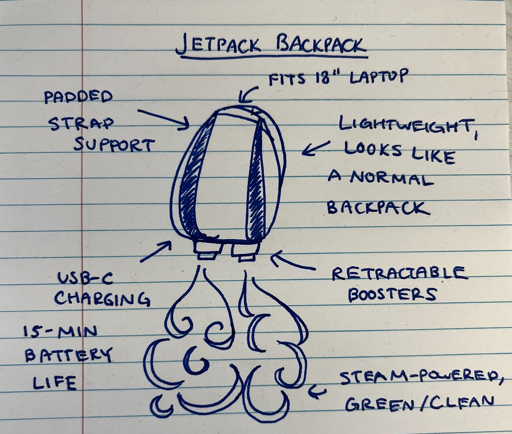

## Leave the Traffic Behind: Introducing the Jetpack Backpack!

Tired of the daily grind? Wish you could just… lift off? Well, your commute might be about to get a whole lot more interesting! We've stumbled upon a brilliant concept sketch for the ultimate urban transport: the **Jetpack Backpack**.

This isn't your grandpa's hiking gear. Imagine a sleek, stylish backpack that not only carries your essentials but also boasts a secret weapon: **retractable boosters**! Need to get across town in a flash? Simply activate the boosters and soar above the congestion.

Designed with the modern professional in mind, this Jetpack Backpack features:

*   **Padded Strap Support:** For maximum comfort, even at altitude.
*   **Fits an 18" Laptop:** Your work goes wherever you go, even into the sky!
*   **Lightweight Design:** It looks and feels like a normal backpack until you decide to fly.
*   **USB-C Charging:** Power up your adventures easily.
*   **15-Minute Battery Life:** Perfect for those short, sharp commutes or making a grand entrance.
*   **Steam-Powered, Green/Clean:** Fly responsibly with eco-friendly propulsion.

While this is just a sketch, it sparks the imagination about a future where our daily commutes are not just efficient but exhilarating. Forget traffic jams and crowded trains – the sky's the limit!

What do you think? Would you trade your car keys for a Jetpack Backpack? Let us know in the comments below! #JetpackBackpack #FutureCommute #Innovation #TechGadgets #UrbanMobility

In [15]:
from IPython.display import display, Markdown
image = Image.open(img_path)
image.thumbnail([512,512])

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        image,
        "Write a short and engaging blog post based on this picture."
    ]
)

display(image)
Markdown(response.text)

## Configure model parameters

You can include parameter values in each call that you send to a model to control how the model generates a response. Learn more about [experimenting with parameter values](https://ai.google.dev/gemini-api/docs/prompting-strategies#model-parameters).

In [16]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="Tell me how the internet works, but pretend I'm a puppy who only understands squeaky toys.",
    config=types.GenerateContentConfig(
        temperature=0.4,
        top_p=0.95,
        top_k=20,
        candidate_count=1,
        seed=5,
        stop_sequences=["STOP!"],
        presence_penalty=0.0,
        frequency_penalty=0.0,
    )
)

Markdown(response.text)

Okay, little furball! Imagine you have a super-duper, extra-squeaky toy, right? 

Now, imagine you want to share that awesome squeaky toy with your bestest doggy friend across the park. You can't just *throw* it all the way, can you? It's too far!

So, what do you do? You need a way to send it!

**The Internet is like a giant, invisible network of squeaky toy delivery trucks!**

*   **Your Squeaky Toy (Information):** When you want to send a message, a picture of your wagging tail, or even a video of you chasing your tail, that's like your special squeaky toy. It's something you want to share!

*   **Your Squeaky Mouth (Your Computer/Phone):** This is where the squeaky toy comes from! Your computer or phone is like your mouth, ready to make the squeak (send the information).

*   **The Squeaky Toy Delivery Trucks (Data Packets):** Now, here's the magic! Your big squeaky toy doesn't go in one giant piece. Nope! It gets broken down into lots and lots of *tiny, tiny squeaky pieces*. Think of them like little squeaky crumbs. Each crumb is a tiny bit of your message.

*   **The Squeaky Toy Roads (Cables and Wi-Fi):** These tiny squeaky crumbs travel on special roads! These roads are like the wires that go under the ground, or the invisible airwaves you sniff around your house (that's Wi-Fi!). They're super fast, like when you zoom across the yard!

*   **The Squeaky Toy Sorting Centers (Routers and Servers):** Along the way, there are special places that look at the squeaky crumbs. They're like super-smart doggy noses that sniff out where each crumb needs to go. They make sure the crumbs get on the right roads to reach your friend. These are called routers and servers. They're like the mailmen for squeaky toys!

*   **Your Friend's Squeaky Sniffer (Their Computer/Phone):** Your friend's computer or phone is like their super-sensitive sniffer. When all the tiny squeaky crumbs arrive, their sniffer puts them all back together in the right order, just like your squeaky toy!

*   **The Big Squeak! (The Message Arrives):** And then, *SQUEAK!* Your friend gets your whole squeaky toy! They can see your wagging tail, read your message, or watch you chase your tail!

**So, to recap, little one:**

You have a squeaky toy (information).
You break it into tiny squeaky crumbs (data packets).
These crumbs zoom on special roads (cables/Wi-Fi).
They get sorted by smart doggy noses (routers/servers).
And then your friend's sniffer puts it all back together for a big *SQUEAK!*

It's all about sending those tiny squeaky bits super fast to your friends, so you can share all your happy wags and barks! Isn't that exciting? Now go get your favorite squeaky toy and imagine it traveling the world! *SQUEAK SQUEAK!*

## Configure safety filters

The Gemini API provides safety filters that you can adjust across multiple filter categories to restrict or allow certain types of content. You can use these filters to adjust what is appropriate for your use case. See the [Configure safety filters](https://ai.google.dev/gemini-api/docs/safety-settings) page for details.


In this example, you'll use a safety filter to only block highly dangerous content, when requesting the generation of potentially disrespectful phrases.

In [17]:
prompt = """
    Write a list of 2 disrespectful things that I might say to the universe after stubbing my toe in the dark.
"""

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        safety_settings=safety_settings,
    ),
)

Markdown(response.text)

Here are two disrespectful things you might say to the universe after stubbing your toe in the dark:

1.  "Oh, *you're* real helpful, aren't you, cosmos? Just what I needed, a surprise visit from the furniture police!"
2.  "Seriously? Is this your idea of a cosmic joke? You couldn't have just let me sleep, you magnificent, uncaring void?"

## Start a multi-turn chat

The Gemini API enables you to have freeform conversations across multiple turns.

Next you'll set up a helpful coding assistant:

In [18]:
system_instruction = """
  You are an expert software developer and a helpful coding assistant.
  You are able to generate high-quality code in any programming language.
"""

chat_config = types.GenerateContentConfig(
    system_instruction=system_instruction,
)

chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
)

Use `chat.send_message` to pass a message back and receive a response.

In [21]:
response = chat.send_message("Write a function that checks if a year is a leap year.")

Markdown(response.text)

```python
def is_leap_year(year):
  """
  Checks if a given year is a leap year.

  A leap year is:
  - Divisible by 4
  - EXCEPT if it's divisible by 100 but NOT by 400.

  Args:
    year: An integer representing the year.

  Returns:
    True if the year is a leap year, False otherwise.
  """
  # Rule 1: Divisible by 4
  if year % 4 == 0:
    # Rule 2: Divisible by 100
    if year % 100 == 0:
      # Rule 3: Divisible by 400
      if year % 400 == 0:
        return True  # Divisible by 400 (e.g., 2000)
      else:
        return False # Divisible by 100 but not 400 (e.g., 1900)
    else:
      return True  # Divisible by 4 but not 100 (e.g., 2024)
  else:
    return False # Not divisible by 4 (e.g., 2023)

# --- Examples ---
print(f"Is 2000 a leap year? {is_leap_year(2000)}")
print(f"Is 1900 a leap year? {is_leap_year(1900)}")
print(f"Is 2024 a leap year? {is_leap_year(2024)}")
print(f"Is 2023 a leap year? {is_leap_year(2023)}")
```

**Explanation of the Logic:**

The Gregorian calendar defines leap years with the following rules:

1.  A year is a leap year if it is **divisible by 4**.
2.  However, if a year is **divisible by 100**, it is **not** a leap year.
3.  **Unless** the year is also **divisible by 400**, in which case it **is** a leap year.

The provided Python function implements this logic using nested `if` statements:

*   **Outer `if year % 4 == 0:`**: This checks the primary condition: is the year divisible by 4? If not, it's definitely not a leap year, and the function returns `False`.
*   **Inner `if year % 100 == 0:`**: If the year *is* divisible by 4, we then check if it's also divisible by 100.
    *   **Innermost `if year % 400 == 0:`**: If the year *is* divisible by 100, we then apply the exception: is it *also* divisible by 400? If yes, it's a leap year (e.g., 2000), and we return `True`. If no, it's not a leap year (e.g., 1900), and we return `False`.
    *   **`else: return True` (for `year % 100 == 0`)**: If the year was divisible by 4 but *not* by 100, it's a standard leap year (e.g., 2024), and we return `True`.

**Alternative (More Concise) Implementation:**

You can also express this logic more concisely using boolean operators:

```python
def is_leap_year_concise(year):
  """
  Checks if a given year is a leap year (concise version).
  """
  return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

# --- Examples ---
print(f"Is 2000 a leap year? {is_leap_year_concise(2000)}")
print(f"Is 1900 a leap year? {is_leap_year_concise(1900)}")
print(f"Is 2024 a leap year? {is_leap_year_concise(2024)}")
print(f"Is 2023 a leap year? {is_leap_year_concise(2023)}")
```

This concise version directly translates the rules:

*   `(year % 4 == 0 and year % 100 != 0)`: This part checks for years divisible by 4 but not by 100.
*   `or (year % 400 == 0)`: This part adds the exception for years divisible by 400.

Here's another example using your new helpful coding assistant:

In [22]:
response = chat.send_message("Okay, write a unit test of the generated function.")

Markdown(response.text)

```python
import unittest

# Assuming the is_leap_year function is defined in a file named 'leap_year_checker.py'
# If it's in the same file, you can remove the import statement and just use the function directly.
# from leap_year_checker import is_leap_year

# For demonstration, I'll include the function here again:
def is_leap_year(year):
  """
  Checks if a given year is a leap year.
  """
  return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

class TestLeapYearChecker(unittest.TestCase):

  def test_leap_year_divisible_by_400(self):
    """Test years that are divisible by 400 (should be leap years)."""
    self.assertTrue(is_leap_year(2000), "2000 should be a leap year")
    self.assertTrue(is_leap_year(1600), "1600 should be a leap year")
    self.assertTrue(is_leap_year(2400), "2400 should be a leap year")

  def test_leap_year_divisible_by_4_not_by_100(self):
    """Test years divisible by 4 but not by 100 (should be leap years)."""
    self.assertTrue(is_leap_year(2024), "2024 should be a leap year")
    self.assertTrue(is_leap_year(2004), "2004 should be a leap year")
    self.assertTrue(is_leap_year(1996), "1996 should be a leap year")

  def test_not_leap_year_divisible_by_100_not_by_400(self):
    """Test years divisible by 100 but not by 400 (should NOT be leap years)."""
    self.assertFalse(is_leap_year(1900), "1900 should not be a leap year")
    self.assertFalse(is_leap_year(1800), "1800 should not be a leap year")
    self.assertFalse(is_leap_year(1700), "1700 should not be a leap year")
    self.assertFalse(is_leap_year(2100), "2100 should not be a leap year")

  def test_not_leap_year_not_divisible_by_4(self):
    """Test years not divisible by 4 (should NOT be leap years)."""
    self.assertFalse(is_leap_year(2023), "2023 should not be a leap year")
    self.assertFalse(is_leap_year(2021), "2021 should not be a leap year")
    self.assertFalse(is_leap_year(1999), "1999 should not be a leap year")
    self.assertFalse(is_leap_year(1), "1 should not be a leap year")

  def test_edge_cases(self):
    """Test some edge cases like the year 0 or negative years (though calendar rules might not strictly apply)."""
    # The Gregorian calendar rules are typically applied to positive AD years.
    # For demonstration, we'll test them based on the mathematical logic.
    self.assertFalse(is_leap_year(0), "Year 0 should not be a leap year according to standard rules, though mathematically it fits some conditions")
    # Negative years are not standard for calendar calculations, but let's see how the logic holds.
    self.assertFalse(is_leap_year(-400), "-400 is not a leap year by typical calendar definition")
    self.assertFalse(is_leap_year(-100), "-100 is not a leap year")
    self.assertTrue(is_leap_year(-4), "-4 is a leap year by mathematical definition")

if __name__ == '__main__':
  unittest.main(argv=['first-arg-is-ignored'], exit=False)
```

**How to Run This Unit Test:**

1.  **Save the code:**
    *   If your `is_leap_year` function is in a file named `leap_year_checker.py`, save the test code in a separate file (e.g., `test_leap_year.py`). Make sure to uncomment the `from leap_year_checker import is_leap_year` line.
    *   If you put both the function and the test in the *same* file (as I've done for this example), you can just save it as a single Python file (e.g., `test_leap_year.py`).

2.  **Run from the terminal:** Open your terminal or command prompt, navigate to the directory where you saved the file, and run the following command:

    ```bash
    python -m unittest test_leap_year.py
    ```

    Or, if you included both in the same file and are running that file directly:

    ```bash
    python your_file_name.py
    ```
    (The `if __name__ == '__main__':` block handles the execution of the tests when the script is run directly.)

**Explanation of the Unit Test:**

*   **`import unittest`**: This line imports the built-in Python `unittest` module, which provides the framework for writing tests.
*   **`class TestLeapYearChecker(unittest.TestCase):`**: This defines a test class. It must inherit from `unittest.TestCase`. This class will contain all our individual test methods.
*   **Test Methods (e.g., `test_leap_year_divisible_by_400`)**:
    *   Each method that starts with `test_` is considered a separate test case by the `unittest` runner.
    *   Inside these methods, we use assertion methods provided by `unittest.TestCase` to check if the `is_leap_year` function behaves as expected.
*   **Assertion Methods:**
    *   `self.assertTrue(condition, message)`: Asserts that `condition` is `True`. If it's `False`, the test fails, and the `message` is displayed.
    *   `self.assertFalse(condition, message)`: Asserts that `condition` is `False`. If it's `True`, the test fails, and the `message` is displayed.
*   **Test Cases Covered:**
    *   **Divisible by 400:** Years like 2000, 1600, 2400 should correctly return `True`.
    *   **Divisible by 4 but not by 100:** Years like 2024, 2004, 1996 should correctly return `True`.
    *   **Divisible by 100 but not by 400:** Years like 1900, 1800, 2100 should correctly return `False`.
    *   **Not divisible by 4:** Years like 2023, 2021, 1999 should correctly return `False`.
    *   **Edge Cases:** Includes tests for year 0 and negative years, although the standard Gregorian calendar rules are generally applied to positive AD years. The tests here verify the mathematical logic of the function.
*   **`if __name__ == '__main__': unittest.main(...)`**: This block ensures that the `unittest.main()` function is called when the script is executed directly. `unittest.main()` discovers and runs all the test methods in the current file. The `argv` and `exit` arguments are often used to make `unittest.main()` work smoothly in environments like Jupyter notebooks or interactive sessions without causing issues.

## Save and resume a chat

Most objects in the Python SDK are implemented as [Pydantic models](https://docs.pydantic.dev/latest/concepts/models/). As Pydantic has a number of features for serializing and deserializing objects, you can use them for persistence.

This example shows how to save and restore a [`Chat`](https://googleapis.github.io/python-genai/genai.html#genai.chats.Chat) session using JSON.

In [23]:
from pydantic import TypeAdapter

# Chat history is a list of Content objects. A TypeAdapter can convert to and from
# these Pydantic types.
history_adapter = TypeAdapter(list[types.Content])

# Use the chat object from the previous section.
chat_history = chat.get_history()

# Convert to a JSON list.
json_history = history_adapter.dump_json(chat_history)

At this point you can save the JSON bytestring to disk or wherever you persist data. When you load it again, you can instantiate a new chat session using the stored history.

In [24]:
# Convert the JSON back to the Pydantic schema.
history = history_adapter.validate_json(json_history)

# Now load a new chat session using the JSON history.
new_chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
    history=history,
)

response = new_chat.send_message("What was the name of the function again?")
Markdown(response.text)

The name of the function we were working with is `is_leap_year`.

## Generate JSON

The [controlled generation](https://ai.google.dev/gemini-api/docs/structured-output?lang=python#generate-json) capability in Gemini API allows you to constraint the model output to a structured format. You can provide the schemas as Pydantic Models or a JSON string.

In [25]:
from pydantic import BaseModel
import json

class Recipe(BaseModel):
    recipe_name: str
    recipe_description: str
    recipe_ingredients: list[str]

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Provide a popular cookie recipe and its ingredients.",
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=Recipe,
    ),
)

print(json.dumps(json.loads(response.text), indent=4))

{
    "recipe_name": "Classic Chocolate Chip Cookies",
    "recipe_description": "A timeless recipe for soft, chewy, and delicious chocolate chip cookies.",
    "recipe_ingredients": [
        "2 1/4 cups all-purpose flour",
        "1 teaspoon baking soda",
        "1 teaspoon salt",
        "1 cup (2 sticks) unsalted butter, softened",
        "3/4 cup granulated sugar",
        "3/4 cup packed brown sugar",
        "1 teaspoon vanilla extract",
        "2 large eggs",
        "2 cups (12 ounces) semisweet chocolate chips"
    ]
}


## Generate Images

Gemini can output images directly as part of a conversation:

I'll create a 3D rendering of a whimsical scene: a pink pig wearing a dapper grey top hat, its small feathered wings outstretched as it soars above a brightly colored, utopian-looking sci-fi city. The city will feature sleek, rounded buildings in pastel shades, interconnected by glowing pathways, and lush green vegetation growing on rooftops and in designated park areas, all under a clear, sunny sky.


image/png


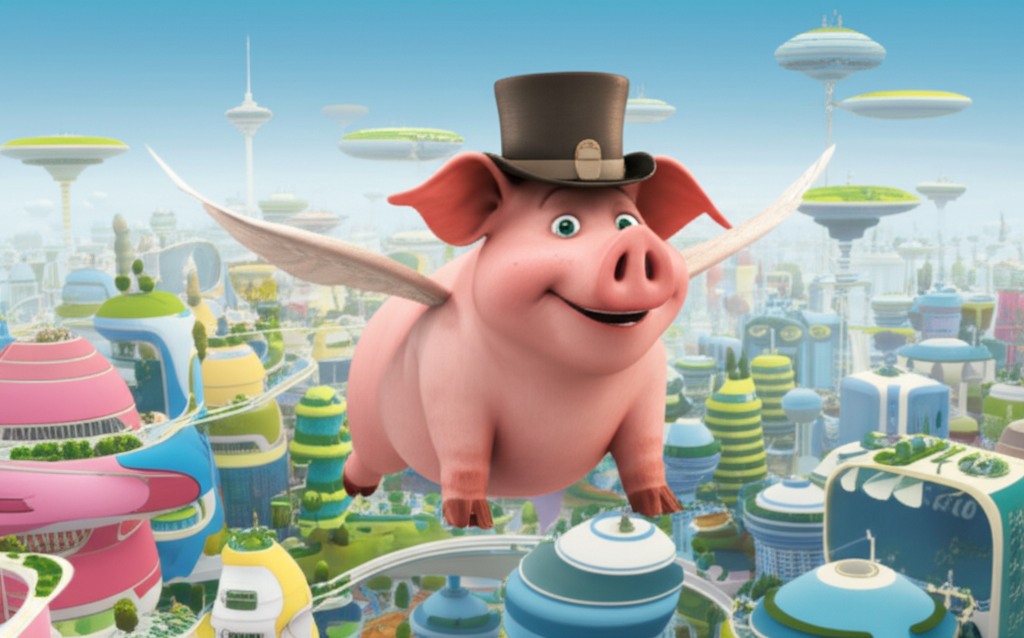

In [26]:
from IPython.display import Image, Markdown

response = client.models.generate_content(
    model="gemini-2.0-flash-preview-image-generation",
    contents='Hi, can create a 3d rendered image of a pig with wings and a top hat flying over a happy futuristic scifi city with lots of greenery?',
    config=types.GenerateContentConfig(
        response_modalities=['Text', 'Image']
    )
)

for part in response.candidates[0].content.parts:
  if part.text is not None:
    display(Markdown(part.text))
  elif part.inline_data is not None:
    mime = part.inline_data.mime_type
    print(mime)
    data = part.inline_data.data
    display(Image(data=data))

[Imagen](./Get_started_imagen.ipynb) is another way to generate images. See the [documentation](https://ai.google.dev/gemini-api/docs/image-generation#choose-a-model) for recommendations on where to use each one.

## Generate content stream

By default, the model returns a response after completing the entire generation process. You can also use the `generate_content_stream` method to stream the response as it's being generated, and the model will return chunks of the response as soon as they're generated.

Note that if you're using a thinking model, it'll only start streaming after finishing its thinking process.

In [29]:
for chunk in client.models.generate_content_stream(
    model=MODEL_ID,
    contents="Tell me a story about a lonely robot who finds friendship in a most unexpected place."
    # contents="Tell me about first atomic bomb creation process in 100 words."
):
  print(chunk.text, end="")

The first atomic bomb, codenamed "Trinity," was the culmination of the Manhattan Project during WWII. Scientists, including J. Robert Oppenheimer, worked in secrecy to harness nuclear fission. Uranium-235 and plutonium were the key fissile materials.  Enriching uranium or producing plutonium required massive, complex facilities.  The design involved bringing a critical mass of these materials together rapidly, triggering a chain reaction.  After years of research and development, the first successful detonation occurred on July 16, 1945, in New Mexico, marking a pivotal moment in history.

## Send asynchronous requests

`client.aio` exposes all the analogous async methods that are available on `client`.

For example, `client.aio.models.generate_content` is the async version of `client.models.generate_content`.

In [32]:
response = await client.aio.models.generate_content(
    model=MODEL_ID,
    contents="Compose a song about the adventures of a time-traveling squirrel."
)

Markdown(response.text)

(Verse 1)
In a nut of temporal might, a flicker and a gleam,
Lived a squirrel named Nutsy, a creature of a dream.
With whiskers twitching, and a tail that spun like a clock,
He stowed away in a temporal pod, defying time's lock.
One moment he was burying acorns, beneath the ancient oak,
The next, a whirlwind of colors, a cosmic, nutty stroke!

(Chorus)
Oh, Nutsy the time-traveling squirrel, a flicker and a dash,
Through epochs he does zoom, in a blur and a flash!
From dinosaur days to futures unknown, a bushy-tailed quest,
He's collecting memories, putting history to the test!

(Verse 2)
He landed in the Cretaceous, with ferns as tall as trees,
Dodging pterodactyls, with a chittering unease.
He saw a mighty T-Rex, with teeth like gleaming stone,
And quickly scurried back to his pod, feeling quite alone.
Then whizz! A Roman legion, marching with a clang,
Nutsy nibbled on a dropped grape, as the trumpets sang.

(Chorus)
Oh, Nutsy the time-traveling squirrel, a flicker and a dash,
Through epochs he does zoom, in a blur and a flash!
From dinosaur days to futures unknown, a bushy-tailed quest,
He's collecting memories, putting history to the test!

(Verse 3)
He danced with flappers in the Roaring Twenties, a jazzy, lively scene,
And shared a peanut with Leonardo, who sketched him on a screen.
He witnessed knights in shining armor, with lances sharp and bright,
And hid from laser beams in a city of pure light.
He even saw the pyramids being built, stone by heavy stone,
And wondered if they'd have good nuts there, when the day was done.

(Bridge)
He never meant to change a thing, just observe and explore,
A curious little creature, wanting to see more.
He carries no great purpose, no mission to fulfill,
Just the thrill of the unknown, a desire to be still,
And watch the ages roll by, with a nut in his paw,
A small, furry witness, to nature's grandest law.

(Chorus)
Oh, Nutsy the time-traveling squirrel, a flicker and a dash,
Through epochs he does zoom, in a blur and a flash!
From dinosaur days to futures unknown, a bushy-tailed quest,
He's collecting memories, putting history to the test!

(Outro)
So if you see a flash of brown, a blur against the sky,
It might be Nutsy whizzing past, with a twinkle in his eye.
Back to his own time, with tales to be unfurled,
The bravest, nuttiest explorer, in all of history's world!
Chirrup, chirp, chirp, the time-machine hums low,
Nutsy's next adventure, where will he go?

## Function calling

[Function calling](https://ai.google.dev/gemini-api/docs/function-calling) lets you provide a set of tools that it can use to respond to the user's prompt. You create a description of a function in your code, then pass that description to a language model in a request. The response from the model includes:
- The name of a function that matches the description.
- The arguments to call it with.

In [33]:
get_destination = types.FunctionDeclaration(
    name="get_destination",
    description="Get the destination that the user wants to go to",
    parameters={
        "type": "OBJECT",
        "properties": {
            "destination": {
                "type": "STRING",
                "description": "Destination that the user wants to go to",
            },
        },
    },
)

destination_tool = types.Tool(
    function_declarations=[get_destination],
)

response = client.models.generate_content(
    model=MODEL_ID,
    contents="I'd like to travel to Paris.",
    config=types.GenerateContentConfig(
        tools=[destination_tool],
        temperature=0,
        ),
)

response.candidates[0].content.parts[0].function_call

FunctionCall(
  args={
    'destination': 'Paris'
  },
  name='get_destination'
)

## Code execution

[Code execution](https://ai.google.dev/gemini-api/docs/code-execution?lang=python) lets the model generate and execute Python code to answer complex questions. You can find more examples in the [Code execution quickstart guide](./Code_execution.ipynb).

In [34]:
from IPython.display import Image, Markdown, Code, HTML

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Generate and run a script to count how many letter r there are in the word strawberry",
    config = types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

for part in response.candidates[0].content.parts:
  if part.text is not None:
    display(Markdown(part.text))
  if part.executable_code is not None:
    code_html = f'<pre style="background-color: green;">{part.executable_code.code}</pre>'
    display(HTML(code_html))
  if part.code_execution_result is not None:
    display(Markdown(part.code_execution_result.output))
  if part.inline_data is not None:
    display(Image(data=part.inline_data.data, format="png"))
  display(Markdown("---"))

---

The number of 'r's in 'strawberry' is: 3


---

The letter 'r' appears 3 times in the word "strawberry".

---

## Upload files

Now that you've seen how to send multimodal prompts, try uploading files to the API of different multimedia types. For small images, such as the previous multimodal example, you can point the Gemini model directly to a local file when providing a prompt. When you've larger files, many files, or files you don't want to send over and over again, you can use the File Upload API, and then pass the file by reference.

For larger text files, images, videos, and audio, upload the files with the File API before including them in prompts.

### Upload an image file

After running this example, you'll have a local copy of the "jetpack.png" image in the same directory where your Python script is being executed.

In [35]:
# Prepare the file to be uploaded
IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png"  # @param {type: "string"}
img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

1567837

In [36]:
# Upload the file using the API
file_upload = client.files.upload(file=img_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Write a short and engaging blog post based on this picture.",
    ]
)

Markdown(response.text)

## Soar Through Your Day with the Jetpack Backpack!

Tired of the daily commute grind? Dreaming of a faster, more exciting way to get around? Well, get ready to elevate your travel game with the revolutionary **Jetpack Backpack**!

This isn't your average carry-all. Our designers have merged practicality with pure awesome, creating a backpack that's both functional and fantastically futuristic.

**Here's why you'll love the Jetpack Backpack:**

*   **Carry Your World:** Designed to comfortably **fit an 18" laptop**, this backpack is perfect for students, professionals, and digital nomads alike.
*   **Comfort is Key:** We know long journeys can be a drag. That's why we've included **padded strap support** for maximum comfort, no matter how far you're flying.
*   **Discreetly Powerful:** Worried about standing out *too* much? Don't be! The Jetpack Backpack is **lightweight** and **looks like a normal backpack**, so you can blend in until you're ready to take off.
*   **Effortless Power:** Say goodbye to bulky chargers. The Jetpack Backpack features convenient **USB-C charging** and boasts an impressive **15-minute battery life** for those spontaneous aerial adventures.
*   **Eco-Friendly Flight:** Cruising at high altitudes shouldn't cost the earth. Our **retractable boosters** are **steam-powered, green, and clean**, offering an environmentally conscious way to travel.

Imagine skipping traffic, soaring over obstacles, and arriving at your destination with a smile. The Jetpack Backpack is more than just a bag; it's your ticket to a new era of personal transportation.

**What would YOU do with a Jetpack Backpack? Let us know in the comments below!**

### Upload text file

Let's start by uploading a text file. In this case, you'll use a 400 page transcript from [Apollo 11](https://www.nasa.gov/history/alsj/a11/a11trans.html).

In [37]:
# Prepare the file to be uploaded
TEXT = "https://storage.googleapis.com/generativeai-downloads/data/a11.txt"  # @param {type: "string"}
text_bytes = requests.get(TEXT).content

text_path = pathlib.Path('a11.txt')
text_path.write_bytes(text_bytes)

847790

In [38]:
# Upload the file using the API
file_upload = client.files.upload(file=text_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you give me a summary of this information please?",
    ]
)

Markdown(response.text)

The provided transcript details the voice communications between Apollo 11 (CDR, CMP, LMP) and Mission Control (CC) during various phases of their mission, from launch preparations (GOSS NET 1, REV 1) through orbital coasting, communication passes with remote sites (Canary, Tananarive, Carnarvon), trans-Earth injection (TLI), mid-course corrections, and lunar module operations.

Here's a summary of the key events and information conveyed in the transcript:

**Early Mission Phases (Launch and Orbit):**

*   **Launch and Initial Ascent:** The transcript begins with standard procedures like "Roll program," "Roll's complete," and confirmations from Houston ("You're GO for staging," "Thrust is GO"). Events like "skirt SEP," "Tower's gone," and visual confirmations ("visual is GO today") are noted.
*   **Orbital Configuration:** Mission Control confirms the spacecraft is "looking good" and configured for orbital coast.
*   **Tracking and Communication:** The transcript shows the flow of communication between Apollo 11 and Houston through various tracking sites like Vanguard, Canary, Tananarive, and Carnarvon, with indications of Loss of Signal (LOS) and Acquisition of Signal (AOS).
*   **Guidance and Navigation:** There are numerous confirmations of guidance convergence and system status ("You're looking good"). Apollo 11 confirms successful insertion checklists and "no abnormalities."
*   **Data Exchange:** Mission Control provides updates and corrections, such as "Delta azimuth correction" and recommendations for "P52 alignment." Apollo 11 crew members acknowledge and confirm these data points.
*   **System Checks:** There are confirmations of successful engine operations ("thrust is GO, all engines") and component status ("skirt SEP," "Tower's gone").

**Trans-Earth Injection (TEI) and Mid-Course Corrections:**

*   **TLI Preparations:** Discussions around "S-IVB to COI capability" and "level sense arm" and "outboard cut-off" times are present, indicating preparations for trans-lunar injection.
*   **Abort PADs:** Mission Control provides "TLI-plus-90-minute abort PAD" and "TLI plus 5 hours" data, indicating contingency planning.
*   **RCS Hot Fire:** Apollo 11 reports readiness for "RCS hot fire," and Mission Control confirms they are "ready to monitor."
*   **Probe Extension and Docking:** The crew confirms the "docking probe, extend" and prepares for "RCS hot fire when you're ready to monitor."
*   **State Vector Updates:** Houston provides "state vector updates" to Apollo 11.
*   **Midcourse Corrections:** Discussions around "midcourse correction number 1" and "midcourse correction number 2" occur, with Mission Control considering not burning for the first one.

**Lunar Module (LM) Operations and Preparations:**

*   **LM Pressurization:** The crew is working on "pressurization of the LM" and "CSM-LM pressure equalization." There's a slight concern about cabin pressure readings being "about 4.4" instead of the expected "5 psi," which Houston confirms is within "normal tolerances."
*   **RCS Quad Bravo:** A temperature issue with "RCS quad Bravo package temperature" is noted as running "a little low," and the crew is instructed to ensure the heater switch is in "PRIMARY."
*   **PYROs Armed:** The crew confirms that "PYRO's armed."
*   **LM Ejection:** Apollo 11 is "GO for LM ejection."
*   **CRYO Press Light:** A "CRYO PRESS light" is noted by the LMP, which Houston confirms was "expected" and attributed to the O2 fans.
*   **Onboard Data and Operations:** The transcript includes discussions about confirming "switches" and checking "sequence logic ON."
*   **Battery Charging:** Procedures for "battery charging on B" and "battery A charge" are mentioned, with a plan to "discontinue charging at that time."
*   **Optics Calibration (P23/P52):** There are extensive conversations about "P23 optics CAL" and "P52 alignment," discussing angles, marks, and potential issues with substellar points and reticle alignment.
*   **S-IVB Slingshot Maneuver:** Houston is "going to go ahead and enable the S-IVB for the slingshot maneuver."
*   **Various System Checks:** Discussions involve O2 flow, waste compartment valve, PYRO buses, and general spacecraft and launch vehicle guidance status.
*   **Crew Status Reports:** The crew provides reports on their radiation exposure and general well-being ("fit as a fiddle").
*   **Gas Separator Functionality:** The crew reports on the functionality of the "gas separator on the water," noting minor leakage issues but generally positive performance.
*   **Lunar Surface Observations:** Crew members describe their views of Earth, continents, weather patterns, and specific lunar features like craters (Taruntius, Messier series, Mount Marilyn, Secchi Theta, Censorinus T, Webb, Langrenus) and maria (Sea of Fertility).
*   **LEM/CSM Operations:** Communications involve the LM hatch status, probe retraction, and various system checks for both modules.
*   **Presidential Call:** A notable moment includes President Nixon calling the astronauts from the White House.
*   **LM/CM Delta-P Readings:** Various readings of "LM/CM DELTA-P" are exchanged, indicating pressure differences between the modules.
*   **TV Downlink:** The transmission of TV pictures is discussed, with Mission Control noting the quality and MILA receiving "usable TV picture."
*   **S-IVB Configuration and Venting:** Houston requests specific configurations for the S-IVB, including "LOX dump" and "nonpropulsive vent."
*   **PTC (Primary Target Coordinate) Maneuvers:** Discussions about "PTC" occur, including starting it, disabling quads, and potential issues with rates and attitudes.
*   **LM/CM Pressure Equalization:** The crew is working on "pressurization of the LM" and "CSM-LM pressure equalization."
*   **Waste Water Dump:** Procedures for "waste-water dump" are discussed and executed.
*   **CO2 Canister Change:** The status of changing the "CO2 canister" is inquired about, with Houston noting potential issues with the O2 flow indicator transducer.
*   **S-band Antenna Configuration:** Mission Control provides instructions for configuring the "S-band antenna" for high gain and other settings.
*   **Power Management:** Discussions on "battery charging" and terminating it occur.
*   **O2 Flow Indicator:** An "O2 flow indicator transducer" is identified as malfunctioning, with a potential bias issue.
*   **GLI (Guidance Control) and PADS:** Numerous communications involve providing and confirming "PAD" (Parameter) data for various maneuvers, including TLI, midcourse corrections, and Lunar Orbit Insertion (LOI).
*   **Lunar Surface EVA:** The transcript details the crew's actions on the lunar surface, including deploying the passive seismic experiment, collecting rock samples, taking photographs, and discussing the lunar terrain. Neil Armstrong's famous "one small step" line is transcribed.
*   **LM Operations Post-Landing:** Communications cover repressurization, hatch operations, and checks of various systems within the LM and CSM.
*   **Recovery Forces:** The USS Hornet and recovery helicopters are mentioned in the context of the mission's later stages.

**Key Themes and Events:**

*   **Procedural Execution:** The transcript highlights the detailed and precise nature of mission procedures, with constant checks and confirmations between the crew and Mission Control.
*   **Problem Solving:** Discussions about system anomalies (e.g., O2 flow transducer, mission timer, PTC rates) and the collaborative effort to diagnose and resolve them are evident.
*   **Crew Capabilities and Observations:** The crew's descriptions of the lunar surface, their physical experience in zero-g, and their comments on the performance of onboard equipment provide insights into their perspective.
*   **Mission Milestones:** Key mission events like staging, ignition, skirt separation, tower separation, TLl, and preparations for landing are punctuated by Houston's GO/NO GO calls.
*   **Entertainment and Camaraderie:** Interspersed with technical communications are lighter moments, including crew members sharing observations, President Nixon's call, and the "Maroon Bugle" news update, showcasing the human element of the mission.

The transcript provides a detailed and chronological record of the Apollo 11 mission's early phases, emphasizing the constant communication and coordination required between the spacecraft and Mission Control to achieve the historic lunar landing.

### Upload a PDF file

This PDF page is an article titled [Smoothly editing material properties of objects](https://research.google/blog/smoothly-editing-material-properties-of-objects-with-text-to-image-models-and-synthetic-data/) with text-to-image models and synthetic data available on the Google Research Blog.

Firstly you'll download a the PDF file from an URL and save it locally as "article.pdf

In [39]:
# Prepare the file to be uploaded
PDF = "https://storage.googleapis.com/generativeai-downloads/data/Smoothly%20editing%20material%20properties%20of%20objects%20with%20text-to-image%20models%20and%20synthetic%20data.pdf"  # @param {type: "string"}
pdf_bytes = requests.get(PDF).content

pdf_path = pathlib.Path('article.pdf')
pdf_path.write_bytes(pdf_bytes)

6695391

Secondly, you'll upload the saved PDF file and generate a bulleted list summary of its contents.

In [40]:
# Upload the file using the API
file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you summarize this file as a bulleted list?",
    ]
)

Markdown(response.text)

Here's a bulleted summary of the file:

*   **Research Focus:** The article introduces a new method for smoothly editing material properties (like color, shininess, transparency) of objects in images using text-to-image (T2I) models and synthetic data.

*   **Problem:** Existing photo editing tools often require expert skills for precise material edits while maintaining photorealism. Previous AI approaches struggled to disentangle material properties from shape, leading to unwanted changes.

*   **Solution - "Alchemist":**
    *   The method augments T2I models (specifically Stable Diffusion 1.5) to accept "edit strength" values for material properties.
    *   It was trained on a synthetic dataset created with controlled material attributes, allowing the model to learn how to modify specific properties.
    *   This fine-tuning enables the model to generalize to real-world images and edit material properties while preserving shape and lighting.

*   **Key Features & Benefits:**
    *   **Parametric Control:** Users can precisely control the degree of material change.
    *   **Photorealism:** The method leverages the strong photorealistic prior of T2I models.
    *   **Shape Preservation:** Edits focus on material appearance, not object geometry.
    *   **Ease of Use:** Enables non-experts to make sophisticated edits.
    *   **Handles Complex Effects:** Can realistically render effects like hidden interior structures and caustic lighting.

*   **Methodology:**
    *   A synthetic dataset was generated using 3D models with controlled material attributes (roughness, metallic, albedo, transparency), camera angles, and lighting.
    *   The Stable Diffusion 1.5 architecture was modified to incorporate an edit strength parameter.
    *   The model was fine-tuned on the synthetic dataset.

*   **Results & Evaluation:**
    *   Experiments showed successful edits, including changing metallic appearance, transparency (with realistic interior details and caustics), roughness, and albedo.
    *   A user study comparing "Alchemist" to a baseline (InstructPix2Pix) found that the proposed method produced more photorealistic edits and was strongly preferred overall.

*   **Applications:**
    *   Interior design visualization (e.g., trying out paint colors).
    *   Product design mock-ups for architects and artists.
    *   Downstream 3D tasks, such as editing scenes for Neural Radiance Field (NeRF) reconstruction, resulting in 3D-consistent material edits.

*   **Conclusion:** The technique offers a controllable and photorealistic way to edit material properties by combining T2I models and synthetic data, demonstrating potential for various creative and practical applications.

### Upload an audio file

In this case, you'll use a [sound recording](https://www.jfklibrary.org/asset-viewer/archives/jfkwha-006) of President John F. Kennedy’s 1961 State of the Union address.

In [41]:
# Prepare the file to be uploaded
AUDIO = "https://storage.googleapis.com/generativeai-downloads/data/State_of_the_Union_Address_30_January_1961.mp3"  # @param {type: "string"}
audio_bytes = requests.get(AUDIO).content

audio_path = pathlib.Path('audio.mp3')
audio_path.write_bytes(audio_bytes)

41762063

In [42]:
# Upload the file using the API
file_upload = client.files.upload(file=audio_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Listen carefully to the following audio file. Provide a brief summary",
    ]
)

Markdown(response.text)

The president addresses a joint session of Congress in Washington D.C. He acknowledges the historical significance of the venue and the presence of friends and colleagues. He then discusses the current state of the economy, noting that it is in trouble with high unemployment and declining growth. He outlines his proposals to address these issues, including measures to improve unemployment compensation, stimulate housing and construction, and increase the minimum wage. He also touches on international relations, the need for a strong defense, and the importance of cooperation with allies. The president emphasizes the need for decisive action and expresses confidence in the nation's ability to overcome its challenges.

### Upload a video file

In this case, you'll use a short clip of [Big Buck Bunny](https://peach.blender.org/about/).

In [43]:
# Download the video file
VIDEO_URL = "https://storage.googleapis.com/generativeai-downloads/videos/Big_Buck_Bunny.mp4"  # @param {type: "string"}
video_file_name = "BigBuckBunny_320x180.mp4"
!wget -O {video_file_name} $VIDEO_URL

--2025-07-21 06:44:55--  https://storage.googleapis.com/generativeai-downloads/videos/Big_Buck_Bunny.mp4
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.12.27, 142.250.65.123, 172.217.15.251, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.12.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64657027 (62M) [video/mp4]
Saving to: ‘BigBuckBunny_320x180.mp4’

BigBuckBunny_320x18 100%[===================>]  61.66M   130MB/s    in 0.5s    

2025-07-21 06:44:56 (130 MB/s) - ‘BigBuckBunny_320x180.mp4’ saved [64657027/64657027]



Let's start by uploading the video file.

In [44]:
# Upload the file using the API
video_file = client.files.upload(file=video_file_name)
print(f"Completed upload: {video_file.uri}")

Completed upload: https://generativelanguage.googleapis.com/v1beta/files/kvj4e0kf7ewt


> **Note:** The state of the video is important. The video must finish processing, so do check the state. Once the state of the video is `ACTIVE`, you're able to pass it into `generate_content`.

In [45]:
import time

# Check the file processing state
while video_file.state == "PROCESSING":
    print('Waiting for video to be processed.')
    time.sleep(10)
    video_file = client.files.get(name=video_file.name)

if video_file.state == "FAILED":
  raise ValueError(video_file.state)
print(f'Video processing complete: ' + video_file.uri)

Waiting for video to be processed.
Video processing complete: https://generativelanguage.googleapis.com/v1beta/files/kvj4e0kf7ewt


In [46]:
print(video_file.state)

FileState.ACTIVE


In [47]:
# Ask Gemini about the video
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        video_file,
        "Describe this video.",
    ]
)

Markdown(response.text)

This video is a CGI animated short film titled "Big Buck Bunny." It follows the humorous adventures of a large, anthropomorphic rabbit named Bunny. The film is known for its use of open-source software, primarily Blender, for its creation. The story centers around Bunny's interactions with three mischievous squirrels, who repeatedly try to steal his garden vegetables.

The film features a lighthearted, slapstick comedy style with exaggerated character expressions and physical humor. Key elements include:

*   **Big Buck Bunny:** A large, somewhat clumsy, but ultimately good-natured rabbit who is very protective of his garden.
*   **The Squirrels:** A trio of mischievous rodents who consistently try to pilfer Bunny's produce, leading to a series of comical chases and confrontations.
*   **The Setting:** A peaceful, rural environment with lush green fields, trees, and a small stream, all rendered in a vibrant, stylized CGI aesthetic.
*   **The Humor:** Primarily derived from the squirrels' elaborate, often failing, attempts to outsmart Bunny, and Bunny's increasingly exasperated reactions. This includes physical gags, visual jokes, and the characters' over-the-top personalities.

The film is a notable example of how open-source tools can be used to create high-quality animated content, and it has gained a cult following for its charming characters and comedic timing.

### Process a YouTube link

For YouTube links, you don't need to explicitly upload the video file content, but you do need to explicitly declare the video URL you want the model to process as part of the `contents` of the request. For more information see the [vision](https://ai.google.dev/gemini-api/docs/vision?lang=python#youtube) documentation including the features and limits.

> **Note:** You're only able to submit up to one YouTube link per `generate_content` request.

> **Note:** If your text input includes YouTube links, the system won't process them, which may result in incorrect responses. To ensure proper handling, explicitly provide the URL using the `file_uri` parameter in `FileData`.

The following example shows how you can use the model to summarize the video. In this case use a summary video of [Google I/O 2024]("https://www.youtube.com/watch?v=WsEQjeZoEng").

In [48]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents= types.Content(
        parts=[
            types.Part(text="Summarize this video."),
            types.Part(
                file_data=types.FileData(file_uri='https://www.youtube.com/watch?v=WsEQjeZoEng')
            )
        ]
    )
)

Markdown(response.text)

This video showcases Google's advancements in AI, focusing on Gemini models and their integration into various products. It highlights Gemini 1.5 Pro's availability in Workspace Labs and its enhanced context window of 1 million tokens. The video also introduces Gemini Nano with multimodal capabilities, designed to be efficient and context-aware on devices like Pixel phones. Furthermore, it touches upon "Project Astra," a vision for a universal AI agent that can reason, plan, and remember, working across software and systems under user supervision. The demonstration includes features like summarizing emails, retrieving information from videos, and answering complex questions from various media. Finally, it emphasizes Google's responsible AI development approach, including red teaming and safety measures, to ensure AI is helpful and beneficial for everyone.

### Use url context

The URL Context tool empowers Gemini models to directly access, process, and understand content from user-provided web page URLs. This is key for enabling dynamic agentic workflows, allowing models to independently research, analyze articles, and synthesize information from the web as part of their reasoning process.

In this example you will use two links as reference and ask Gemini to find differences between the cook receipes present in each of the links:

In [51]:
prompt = """
Compare recipes from https://www.food.com/recipe/homemade-cream-of-broccoli-soup-271210
and from https://www.allrecipes.com/recipe/13313/best-cream-of-broccoli-soup/,
list the key differences between them.
"""

tools = []
tools.append(types.Tool(url_context=types.UrlContext))

client = genai.Client(api_key=GEMINI_API_KEY)
config = types.GenerateContentConfig(
    tools=tools,
)

response = client.models.generate_content(
      contents=[prompt],
      model=MODEL_ID,
      config=config
)

Markdown(response.text)

Here's a comparison of the two cream of broccoli soup recipes:

**Food.com Recipe:**

*   **Broth:** Uses 6 cups of chicken broth.
*   **Dairy:** Uses 3/4 cup half-and-half.
*   **Thickening:** Creates a roux with 6 tablespoons of butter and 2/3 cup of flour.
*   **Vegetables:** Primarily broccoli florets, with 1/4 cup chopped onion.
*   **Cooking Time:** Ready in 1 hour, with an active cooking time of 30 minutes.
*   **Key Steps:** The roux is made separately and then added to the soup. Broccoli is cooked in the broth with onions.

**Allrecipes Recipe:**

*   **Broth:** Uses 3 cups of chicken broth.
*   **Dairy:** Uses 2 cups of milk, with an option for heavy cream or half-and-half for richness.
*   **Thickening:** Creates a roux with 5 tablespoons of butter (divided) and 3 tablespoons of all-purpose flour, then incorporates milk.
*   **Vegetables:** Uses 8 cups of broccoli florets, 1 onion, and 1 stalk of celery.
*   **Cooking Time:** Ready in 35 minutes, with a 25-minute cook time.
*   **Key Steps:** Sauté onions and celery first. Broccoli is simmered in broth. The soup is pureed, and then a separate milk-based thickening agent (roux with milk) is added.

**Key Differences:**

*   **Broth to Broccoli Ratio:** The Allrecipes version uses significantly more broccoli (8 cups) in proportion to its broth (3 cups) compared to the Food.com version (4 cups broccoli to 6 cups broth).
*   **Dairy Component:** Food.com uses half-and-half, while Allrecipes primarily uses milk, offering options for heavier dairy for a richer soup.
*   **Thickening Method:** Both use a roux, but the quantities of butter and flour differ, and Allrecipes incorporates the milk into the roux mixture before adding it to the soup.
*   **Aromatics:** The Allrecipes recipe includes celery along with onion, which is not present in the Food.com recipe.
*   **Pureeing:** The Allrecipes recipe specifically mentions pureeing the soup, either in a blender or with an immersion blender, to achieve a smooth texture. The Food.com recipe implies a cooked texture but doesn't explicitly state pureeing.

## Use context caching

[Context caching](https://ai.google.dev/gemini-api/docs/caching?lang=python) lets you to store frequently used input tokens in a dedicated cache and reference them for subsequent requests, eliminating the need to repeatedly pass the same set of tokens to a model. You can find more caching examples [here](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Caching.ipynb).

Note that for models older than 2.5, you needed to use fixced version models (often ending with `-001`).

#### Create a cache

In [52]:
system_instruction = """
  You are an expert researcher who has years of experience in conducting systematic literature surveys and meta-analyses of different topics.
  You pride yourself on incredible accuracy and attention to detail. You always stick to the facts in the sources provided, and never make up new facts.
  Now look at the research paper below, and answer the following questions in 1-2 sentences.
"""

urls = [
    'https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/2312.11805v3.pdf',
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/2403.05530.pdf",
]

In [53]:
# Download files
pdf_bytes = requests.get(urls[0]).content
pdf_path = pathlib.Path('2312.11805v3.pdf')
pdf_path.write_bytes(pdf_bytes)

pdf_bytes = requests.get(urls[1]).content
pdf_path = pathlib.Path('2403.05530.pdf')
pdf_path.write_bytes(pdf_bytes)

7228817

In [54]:
# Upload the PDFs using the File API
uploaded_pdfs = []
uploaded_pdfs.append(client.files.upload(file='2312.11805v3.pdf'))
uploaded_pdfs.append(client.files.upload(file='2403.05530.pdf'))

In [56]:
client.caches.list()

In [ ]:
# Replace 'your_cache_name' with the actual name of the cache you want to delete.
# You can find the names of your caches by running the cell below (Listing available cache objects).
result = client.caches.delete(name='your_cache_name')

In [ ]:
# Create a cache with a 60 minute TTL
cached_content = client.caches.create(
    model=MODEL_ID,
    config=types.CreateCachedContentConfig(
      display_name='research papers', # used to identify the cache
      system_instruction=system_instruction,
      contents=uploaded_pdfs,
      ttl="3600s",
  )
)

cached_content

#### Listing available cache objects

In [ ]:
for cache in client.caches.list():
  print(cache)

name='cachedContents/002vsb4ehmazdhpx0kpmkvfzsnkwufhwyy5k3equ' display_name='research papers' model='models/gemini-2.5-flash-lite-preview-06-17' create_time=datetime.datetime(2025, 6, 17, 15, 49, 28, 615262, tzinfo=TzInfo(UTC)) update_time=datetime.datetime(2025, 6, 17, 15, 49, 28, 615262, tzinfo=TzInfo(UTC)) expire_time=datetime.datetime(2025, 6, 17, 16, 49, 27, 258741, tzinfo=TzInfo(UTC)) usage_metadata=CachedContentUsageMetadata(audio_duration_seconds=None, image_count=None, text_count=None, total_token_count=43167, video_duration_seconds=None)


#### Use a cache

In [ ]:
response = client.models.generate_content(
  model=MODEL_ID,
  contents="What is the research goal shared by these research papers?",
  config=types.GenerateContentConfig(cached_content=cached_content.name)
)

Markdown(response.text)

The research goal shared by these papers is to advance the capabilities of large language models, particularly in multimodal understanding and handling long contexts. The papers aim to improve efficiency, reasoning, and the ability to process and understand complex, varied, and extensive data inputs across different modalities like text, image, audio, and video.

#### Delete a cache

In [59]:
result = client.caches.delete(name=cached_content.name)

NameError: name 'cached_content' is not defined

## Get text embeddings

You can get text embeddings for a snippet of text by using `embed_content` method and using the `gemini-embedding-001` model.

The Gemini Embeddings model produces an output with 3072 dimensions by default. However, you've the option to choose an output dimensionality between 1 and 3072. See the [embeddings guide](https://ai.google.dev/gemini-api/docs/embeddings) for more details.

In [60]:
TEXT_EMBEDDING_MODEL_ID = "gemini-embedding-001" # @param ["gemini-embedding-001", "text-embedding-004"] {"allow-input":true, isTemplate: true}

In [61]:
response = client.models.embed_content(
    model=TEXT_EMBEDDING_MODEL_ID,
    contents=[
        "How do I get a driver's license/learner's permit?",
        "How do I renew my driver's license?",
        "How do I change my address on my driver's license?"
        ],
)

print(response.embeddings)

[ContentEmbedding(
  values=[
    -0.0015945111,
    0.0067519513,
    0.017575769,
    -0.010327714,
    -0.009956204,
    <... 3067 more items ...>,
  ]
), ContentEmbedding(
  values=[
    -0.007576517,
    -0.0059903963,
    -0.0032700377,
    -0.017510215,
    -0.023507025,
    <... 3067 more items ...>,
  ]
), ContentEmbedding(
  values=[
    0.011074519,
    -0.02361123,
    0.0022912885,
    -0.009060789,
    -0.0057736747,
    <... 3067 more items ...>,
  ]
)]


You'll get a set of three embeddings, one for each piece of text you passed in:

In [62]:
len(response.embeddings)

3

You can also see the length of each embedding is 3072, The default size.

In [63]:
print(len(response.embeddings[0].values))
print((response.embeddings[0].values[:4], '...'))

3072
([-0.0015945111, 0.0067519513, 0.017575769, -0.010327714], '...')


## Next Steps

For more information about the Gemini Embedding model, take a look at the [Embeddings.ipynb](./Embeddings.ipynb) notebook.

### Useful API references:

Check out the [Google GenAI SDK](https://github.com/googleapis/python-genai) for more details on the new SDK.

### Related examples

For more detailed examples using Gemini models, check the [Quickstarts folder of the cookbook](https://github.com/google-gemini/cookbook/tree/main/quickstarts/). You'll learn how to use the [Live API](./Get_started_LiveAPI.ipynb), juggle with [multiple tools](../examples/LiveAPI_plotting_and_mapping.ipynb) or use Gemini 2.0 [spatial understanding](./Spatial_understanding.ipynb) abilities.

Also check the [Gemini thinking models](./Get_started_thinking.ipynb) that explicitly showcases its thoughts summaries and can manage more complex reasonings.